In [1]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import random_split

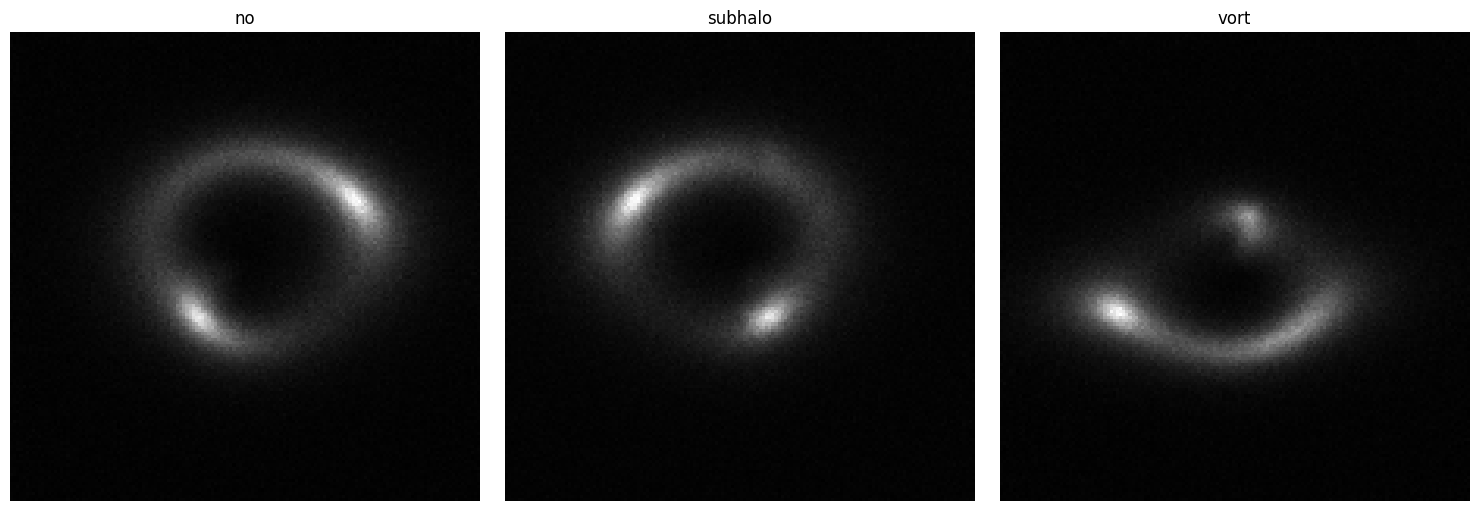

<Figure size 640x480 with 0 Axes>

In [2]:
no = np.load("/kaggle/input/datasets/adman007/deeplense/dataset/train/no/1.npy")
subhalo = np.load("/kaggle/input/datasets/adman007/deeplense/dataset/train/sphere/1.npy")
vortex = np.load("/kaggle/input/datasets/adman007/deeplense/dataset/train/vort/1.npy")

def plot_samples_horizontally(samples_dict):
    plt.figure(figsize=(15, 5))
    
    for i, (label, img) in enumerate(samples_dict.items()):
        plt.subplot(1, 3, i + 1)
        plt.imshow(img[0], cmap="gray")
        plt.title(label)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

samples = {
    "no": no,
    "subhalo": subhalo,
    "vort": vortex
}

plot_samples_horizontally(samples)
plt.savefig("horizontal_samples_input_images.png")

In [3]:
torch.manual_seed(42)
np.random.seed(42)

NUM_CLASSES = 3
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                    self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float()
        
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
        
        if self.transform:
            image = self.transform(image)
                    
        return image, label

In [5]:
IMAGE_SIZE = 240 

transform = {
    "train": transforms.Compose([
        transforms.Resize(256), 
        transforms.CenterCrop(IMAGE_SIZE),
        
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ]),
    "val": transforms.Compose([
        transforms.Resize(IMAGE_SIZE), 
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    ])
}

In [6]:
def load_data(data_dir):
    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')
    
    train_dir_dataset = GravitationalLensingDataset(train_dir, transform=transform['train'])
    test_dataset = GravitationalLensingDataset(val_dir, transform=transform['val'])

    num_images = len(train_dir_dataset)

    # number of images for training (90%) and testing (10%)
    train_size = int(num_images * 0.9)
    val_size = num_images - train_size

    # Split the dataset
    train_dataset, val_dataset = random_split(train_dir_dataset, [train_size, val_size])
    print(len(train_dataset), len(val_dataset), len(test_dataset))
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
    
    return train_loader, val_loader, test_loader, train_dir_dataset.class_to_idx

In [7]:
def initialize_model():

    model = models.efficientnet_b1(weights=None) 
    weights_path = '/kaggle/input/datasets/adman007/efficientnet-b1/efficientnet_b1_rwightman-bac287d4.pth'

    if os.path.exists(weights_path):
        print(f"Loading pretrained weights from: {weights_path}")
        state_dict = torch.load(weights_path, map_location=DEVICE)
        model.load_state_dict(state_dict)
    else:
        raise FileNotFoundError(f"Weights not found! Check path: {weights_path}")

    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    
    return model

In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_name):
    model.to(DEVICE)
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Add tqdm progress bar for training
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            train_pbar.set_postfix({'loss': loss.item(), 'acc': correct/total})
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        
        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        
        # Add tqdm progress bar for validation
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
                val_pbar.set_postfix({'loss': loss.item(), 'acc': val_correct/val_total})
        
        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_correct / val_total
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}')
        
        # Save best model
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            torch.save(model.state_dict(), f'best_efficientNet_b1_classification_model.pt')
            print(f'New best model saved with validation accuracy: {best_val_acc:.4f}')
    
    return model, history

In [9]:
data_dir = '/kaggle/input/datasets/adman007/deeplense/dataset'  
    
train_loader, val_loader, test_loader, class_to_idx = load_data(data_dir)

model = initialize_model()
model = torch.compile(model, mode="default")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

27000 3000 7500
Loading pretrained weights from: /kaggle/input/datasets/adman007/efficientnet-b1/efficientnet_b1_rwightman-bac287d4.pth


## Training EfficientNet_b1

In [10]:
import logging
logging.getLogger("torch._inductor.utils").setLevel(logging.ERROR)
logging.getLogger("torch.utils._sympy.interp").setLevel(logging.ERROR)

In [11]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, model_name="resnet34")

Epoch 1/50 [Train]:   0%|          | 0/211 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Epoch 1/50 [Val]: 100%|██████████| 24/24 [00:18<00:00,  1.27it/s, loss=0.395, acc=0.782]


Epoch 1/50: Train Loss: 0.7876, Train Acc: 0.6159, Val Loss: 0.5231, Val Acc: 0.7823
New best model saved with validation accuracy: 0.7823


Epoch 2/50 [Val]: 100%|██████████| 24/24 [00:02<00:00,  9.95it/s, loss=0.27, acc=0.837] 


Epoch 2/50: Train Loss: 0.3894, Train Acc: 0.8479, Val Loss: 0.4134, Val Acc: 0.8373
New best model saved with validation accuracy: 0.8373


Epoch 3/50 [Val]: 100%|██████████| 24/24 [00:02<00:00,  8.98it/s, loss=0.261, acc=0.905]


...

Epoch 48/50: Train Loss: 0.0660, Train Acc: 0.9762, Val Loss: 0.1268, Val Acc: 0.9587


Epoch 49/50 [Val]: 100%|██████████| 24/24 [00:02<00:00, 10.11it/s, loss=0.199, acc=0.967] 


Epoch 49/50: Train Loss: 0.0686, Train Acc: 0.9751, Val Loss: 0.0949, Val Acc: 0.9667
New best model saved with validation accuracy: 0.9667


Epoch 50/50 [Val]: 100%|██████████| 24/24 [00:02<00:00, 10.24it/s, loss=0.0606, acc=0.95] 

Epoch 50/50: Train Loss: 0.0666, Train Acc: 0.9774, Val Loss: 0.1468, Val Acc: 0.9497


In [12]:
def evaluate_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    all_probs = [] 
    
    test_pbar = tqdm(test_loader, desc='Evaluating on test set')
    with torch.no_grad():
        for inputs, labels in test_pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            probs = torch.nn.functional.softmax(outputs, dim=1)  
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            
            test_pbar.set_postfix({'loss': loss.item(), 'acc': test_correct/test_total})
    
    test_loss = test_loss / len(test_loader.dataset)
    test_acc = test_correct / test_total
    
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')
    
    cm = confusion_matrix(all_labels, all_preds)
    
    all_labels_np = np.array(all_labels)
    all_probs_np = np.array(all_probs)
    
    n_classes = all_probs_np.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        binary_labels = (all_labels_np == i).astype(int)
        class_probs = all_probs_np[:, i]
        
        fpr[i], tpr[i], _ = roc_curve(binary_labels, class_probs)
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    macro_roc_auc = sum(roc_auc.values()) / n_classes
    print(f'Macro-averaged ROC AUC: {macro_roc_auc:.4f}')
    
    return test_loss, test_acc, cm, all_labels, all_preds, all_probs_np, fpr, tpr, roc_auc, macro_roc_auc


def plot_roc_curves(fpr, tpr, roc_auc):
    plt.figure(figsize=(10, 8))
    
    for i in fpr.keys():
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'ROC curve for class {i} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)    
    plt.savefig("ROC-AUC curve_4", dpi=300, bbox_inches='tight')   
    plt.show()


def plot_history(history, num_epochs=NUM_EPOCHS):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epoch')
    plt.xlim(0, num_epochs - 1)  # Set x-axis range
    plt.ylim(0, 1)  # Loss should ideally be positive, but limiting to 0-1 depends on the problem
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epoch')
    plt.xlim(0, num_epochs - 1)  # Set x-axis range
    plt.ylim(0, 1)  # Accuracy is always between 0 and 1
    
    plt.tight_layout()
    plt.savefig('training_history_4.png')
    plt.show()


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix_4.png')
    plt.show()

In [13]:
test_loss, test_acc, cm, all_labels, all_preds, all_probs, fpr, tpr, roc_auc, macro_roc_auc = evaluate_model(model, test_loader, criterion)

Evaluating on test set: 100%|██████████| 59/59 [00:19<00:00,  3.06it/s, loss=0.121, acc=0.964] 

Test Loss: 0.1161, Test Accuracy: 0.9636
Macro-averaged ROC AUC: 0.9944


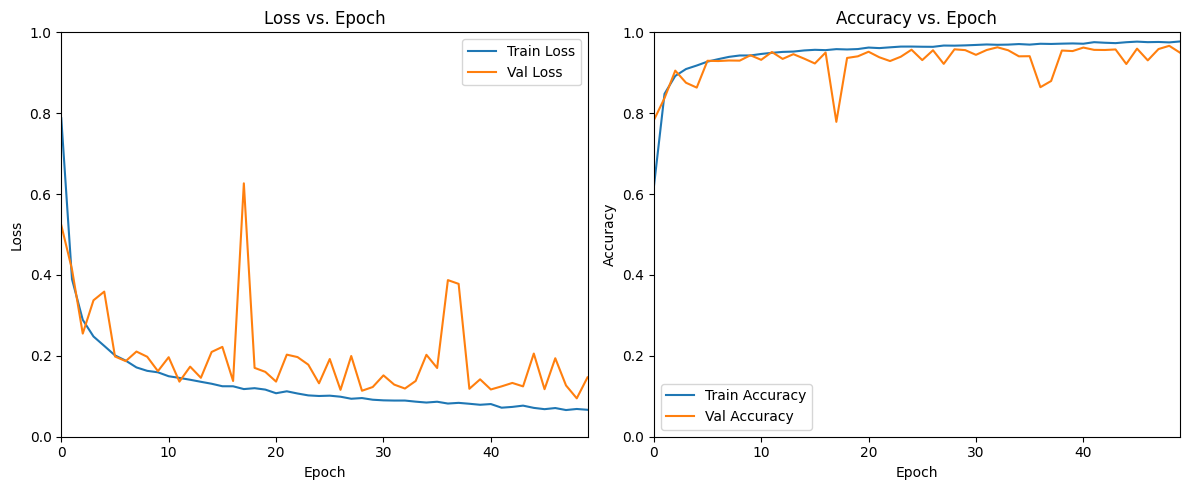

In [14]:
plot_history(history)

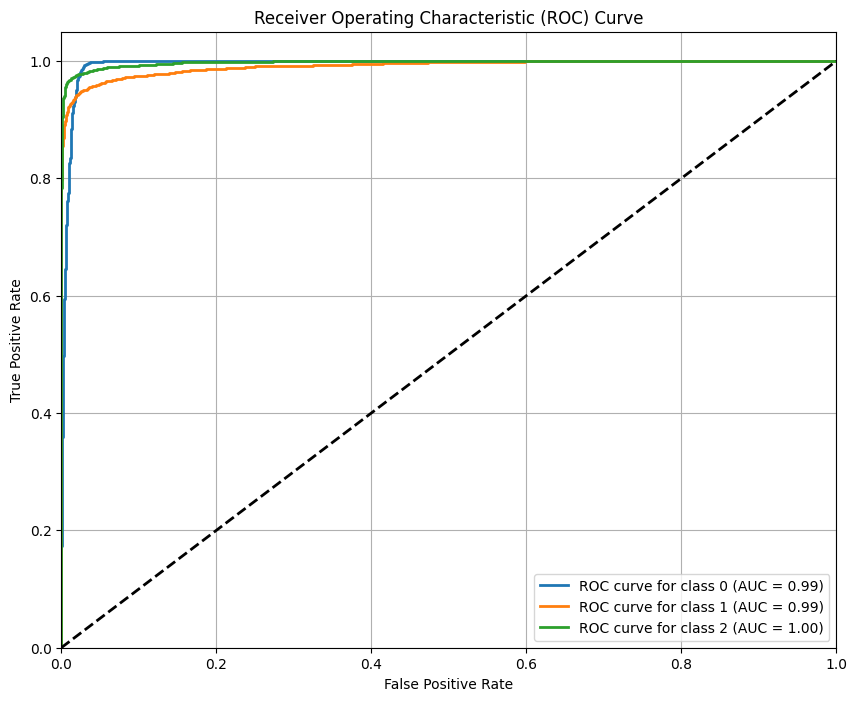

In [15]:
plot_roc_curves(fpr, tpr, roc_auc)

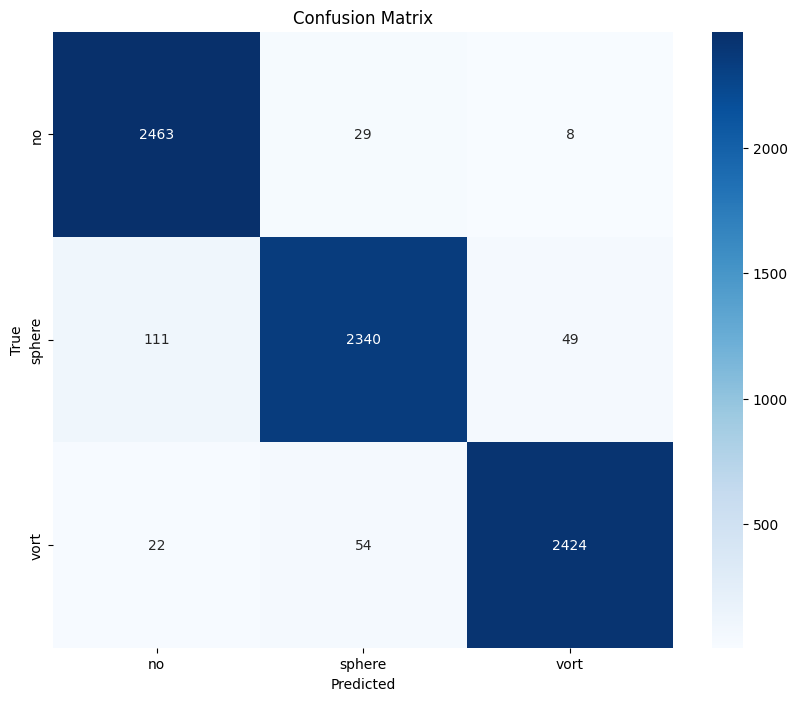

In [16]:
class_names = [k for k, v in sorted(class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(cm, class_names)

## Inference code

In [18]:
def load_classification_model(ckpt_path, model_name, num_classes=3, compile=False, use_half_precision=False):
    from collections import OrderedDict
    

    if model_name == 'efficientnet_b1':
        model = models.efficientnet_b1(weights=None)

        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = torch.nn.Linear(num_ftrs, num_classes)
    else:
        raise ValueError("Unsupported model type. Use 'efficientnet_b1'.")

    checkpoint = torch.load(ckpt_path, map_location=torch.device('cpu'))


    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint

    
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        
        name = k.replace("_orig_mod.", "")
        new_state_dict[name] = v
    
    model.load_state_dict(new_state_dict)


    if compile:
        model = torch.compile(model, mode="reduce-overhead")
    
    if use_half_precision:
        model = model.half()

    model = model.to(DEVICE)
    return model.eval()


efnet_ckpt_path = '/kaggle/working/best_efficientNet_b1_classification_model.pt' 
efnet_model = load_classification_model(
    efnet_ckpt_path, 
    model_name="efficientnet_b1", 
    compile=True, 
    use_half_precision=True
)

In [19]:
def classify_image(model, image_path):
    model.to(DEVICE)
    image = np.load(image_path)
    image = torch.from_numpy(image).to(DEVICE, dtype=next(model.parameters()).dtype)
    image = image.unsqueeze(0)
    image = image.repeat(1, 3, 1, 1)
    image = transforms.Resize(256)(image)
    image = transforms.CenterCrop(224)(image)
    image = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])(image)
    class_names = ['no', 'sphere', 'vort']
    probs = []
    with torch.no_grad():
        output = model(image)
        probabilities = torch.nn.functional.softmax(output, dim=1)[0]

        for j, prob in enumerate(probabilities):
            probs.append(f"{class_names[j]}: {prob.item():.4f} ({prob.item()*100:.2f}%)")
    return probs

In [20]:
def measure_latency(model, iters=100):
    image_path = '/kaggle/input/datasets/adman007/deeplense/dataset/train/vort/1.npy'
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    # warm up gpu
    for _ in range(5):
        classify_image(model, image_path=image_path)

    start_event.record()
    for _ in tqdm(range(iters)):
        classify_image(model, image_path=image_path)
    end_event.record()

    torch.cuda.synchronize()
    elapsed_time = start_event.elapsed_time(end_event) / iters
    return elapsed_time

In [23]:
eff_b1_latency = measure_latency(efnet_model, iters=100)


100%|██████████| 100/100 [00:00<00:00, 331.86it/s]


In [24]:
print(f"EfficientNet_b1 Latency: {eff_b1_latency:.4f} ms")

EfficientNet_b1 Latency: 3.0243 ms
